#### Exploring and visualizing data

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

/Users/suhas/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
## load an .npy file (a structure) in the "Data" folder
data_dir = '/Users/kshiti/ML4MaterialsScience-course/data'
str_list=os.listdir(data_dir) #returns a list containing the names of the entries in the directory

len(str_list) 

361

In [4]:
data= np.load(data_dir + '/' + str_list[1])
print('type of data',type(data))
print('data dimension',data.ndim)    #File contains three dimensional array
print('shape of data',data.shape )   # Axis are 100 units in each of the three dimensions

type of data <class 'numpy.ndarray'>
data dimension 3
shape of data (100, 100, 100)


#### Visualising microstructure

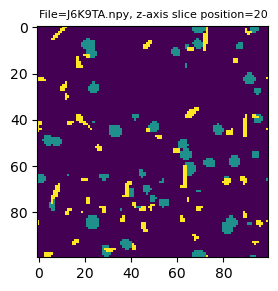

In [9]:
zSlicePosition = 20      # position of a microstructure slice along the z-axis for visualisation
data = np.load(data_dir+'/'+str_list[42]) #Visualising image 42 on the data list
dataSlice=data[:,:,zSlicePosition]    # slice at the the x3 dimension and retain x1,x2 untouched

plt.figure(figsize = (4,3))
plt.imshow(dataSlice,interpolation='nearest')
plt.title(f'File={str_list[42]}, z-axis slice position={zSlicePosition}', fontsize=8)
plt.show()

In [11]:
print(dataSlice)
print(np.shape(dataSlice))
print(np.unique(dataSlice))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
(100, 100)
[0 1 2]


The above parameter "dataSlice" is a 100x100 array, with each element taking one out of the unique values 0, 1 or 2. 

Each point of the array corresponds to a spatial coordinate of the synthetic material structure. The values of each array element (0,1,or 2) represent the constituent compound occupying that spatial coordinate.

- 0 -> Silica (SiO2)
- 1 -> ß-SiC
- 2 -> Segregated Carbon

In the next section, the (2D) volume fraction of each constitutent for a given slice is calculated for the first four files in the dataset.

#### Calculating Volume Fractions of Different Phases

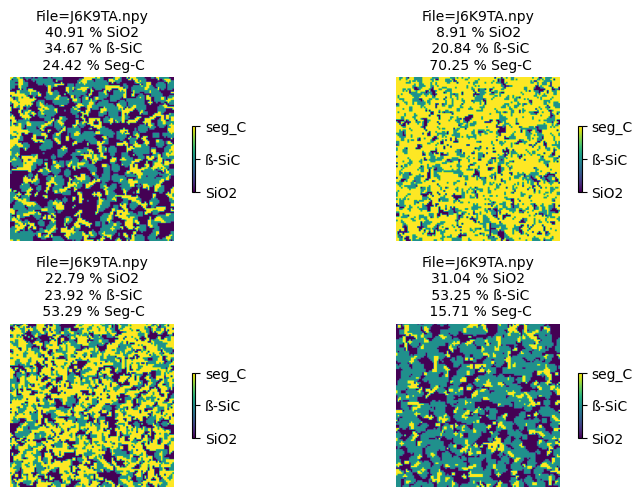

In [22]:
#Calculation of phase volume fraction in 2D slices
plt.rcParams["figure.figsize"] = [8, 10]      # width and height of the figure
plt.rcParams["figure.autolayout"] = True

zSlicePosition = 10      # position of a microstructure slice along the z-axis for visualisation

for i in range(len(str_list[:4])):  # first 4 files
    n0,n1,n2 = 0,0,0                # reset iterative variable for volume fraction of each constituent
    data = np.load(data_dir+'/'+str_list[i])
    dataSlice=data[:,:,zSlicePosition]    # slice at the the x3 dimension and leave x1,x2 untouched


    plt.subplot(4,2,i+1)
    plt.title("Volume fractions of selected compositions")
    plt.imshow(dataSlice)               # Save the plotted images in memory
    plt.axis('off')
    #This code iterates through every pixel, counts how many pixels have values 0, 1, or 2, and stores the totals in n0, n1, and n2.
    for pixel in np.nditer(dataSlice):   # nditer(): multi-D iterator to iterate over arrays
        if pixel == 1:
            n1 += 1
        elif pixel == 2:
            n2 += 1
        elif pixel == 0:
            n0 += 1
    TotalPixels = dataSlice.size
    plt.title(str_list[i]+" @z="+str(zSlicePosition),fontsize=14)
    plt.title(f'File={str_list[42]}\n{str(n0*100/TotalPixels)} % SiO2\n {str(n1*100/TotalPixels)} % ß-SiC\n {str(n2*100/TotalPixels)} % Seg-C',fontsize=10)

    cbar = plt.colorbar(ticks=[0, 1, 2],shrink=0.4)  

    cbar.set_ticklabels(['SiO2', 'ß-SiC', 'seg_C'])  # Setting corresponding tick labels


plt.show()  # show sketch and plotted images
